In [1]:
# imports
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from skimage.feature import peak_local_max

In [2]:
# 0: channel 640, 1: channel 488, 2 Bright Field, 3: folder name
data = []

dir = os.getcwd()
dir_data = os.getcwd()[:dir.rfind('\\')] + "\\data"
for folder in os.listdir(dir_data):
    new_img = [None, None, None, folder]
    for file in os.listdir(os.path.join(dir_data, folder)):
        if str(file).endswith("colour0.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[0] = np.array(tempImg)
            new_img[0] = np.array([i[tempImg.shape[1]//2:tempImg.shape[1]] for i in tempImg])
        elif str(file).endswith("colour1.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[1] = np.array(tempImg)
            new_img[1] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
        elif str(file).endswith("colour2.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[2] = np.array(tempImg)
            new_img[2] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
    data.append(new_img)

In [3]:
# image read function
def printImg(imgs, map=None):
    fig = plt.figure(figsize=(8,15))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(imgs[i], cmap=map)
        plt.axis('off')

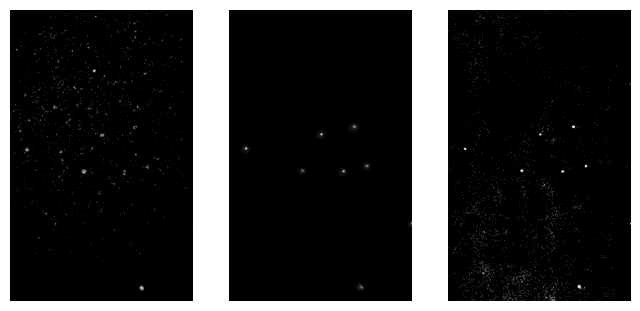

In [11]:
# boundary threshold
data_i = data[0][0:3].copy()
imgsTest = data_i.copy()
for i in range(len(imgsTest)):
    imgsTest_i = imgsTest[i].copy()
    max_i = np.amax(imgsTest_i)
    agv_i = np.mean(imgsTest_i)
    qtl_i = np.percentile(imgsTest_i, 99)
    # print(max_i)
    # print(agv_i)
    # print(qtl_i)
    threshold = qtl_i # 65535
    imgsTest_i[imgsTest_i < threshold] = 0
    # bound = cv2.inRange(imgsTest[i], int(np.amin(imgsTest[i]))-10, int(np.amax(imgsTest[i]))+10)
    imgsTest[i] =  imgsTest_i
printImg(imgsTest, "gray")

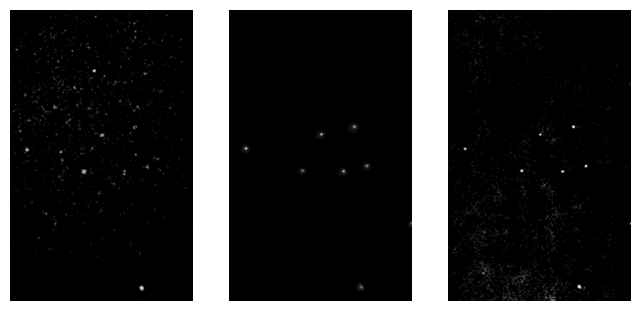

In [12]:
# test blur
imgsTest_blur = imgsTest.copy()
for i in range(len(imgsTest_blur)):
    blur = cv2.GaussianBlur(imgsTest_blur[i],(3,3), 4)
    imgsTest_blur[i] = blur
printImg(imgsTest_blur, "gray")